In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
file_path = "Dataset_customer360/customers.csv"
df = pd.read_csv(file_path)
df.head()

,customer_id,age,gender,region,income,signup_date
0,CUST00000,56,Male,North,20089.18,2022-08-30
1,CUST00001,69,Male,Central,55869.83,2023-02-03
2,CUST00002,46,Male,East,24074.44,2024-04-13
3,CUST00003,32,Female,East,22368.14,2023-10-08
4,CUST00004,60,Male,South,42868.50,2025-06-18


OVERVIEW OF DATA

In [45]:
# df.info()
# df.describe()
# a = df['age'].unique()
# a.sort()
# len(a)
df['age'].value_counts()



age
64    107
52    106
66    105
25    104
43    103
54    101
38    101
45    101
62     99
42     96
51     96
50     96
61     96
34     95
71     94
49     94
68     94
28     94
39     93
72     92
46     91
53     91
40     91
41     91
29     90
21     90
47     90
19     89
70     88
58     88
57     87
23     87
30     87
56     86
20     85
35     84
32     84
55     83
22     83
31     83
37     83
26     83
74     83
73     82
36     82
18     82
63     79
69     79
67     79
27     75
59     73
33     71
60     68
65     68
44     66
24     66
48     66
Name: count, dtype: int64

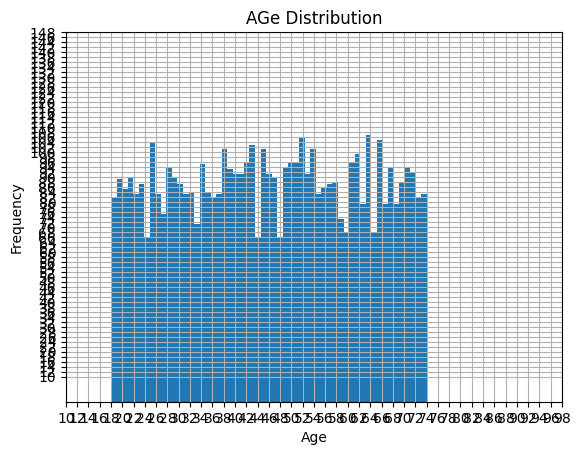

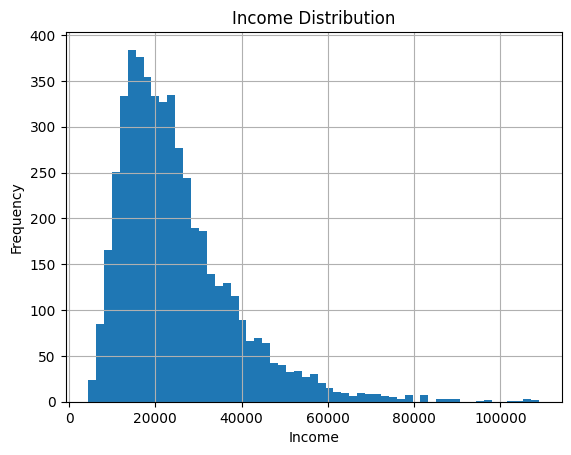

In [44]:
hist = df['age'].hist(bins=57,)
plt.yticks(np.arange(10, 150, 2))
plt.xticks(np.arange(10, 100, 2))
plt.title('AGe Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

hist = df['income'].hist(bins=57,)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='gender'>

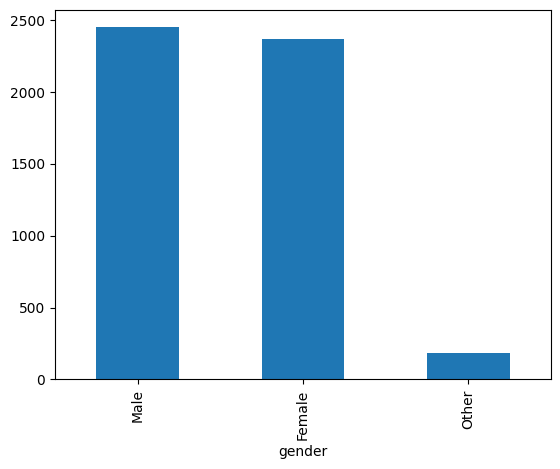

In [54]:
df['gender'].value_counts().plot.bar()


<Axes: xlabel='region'>

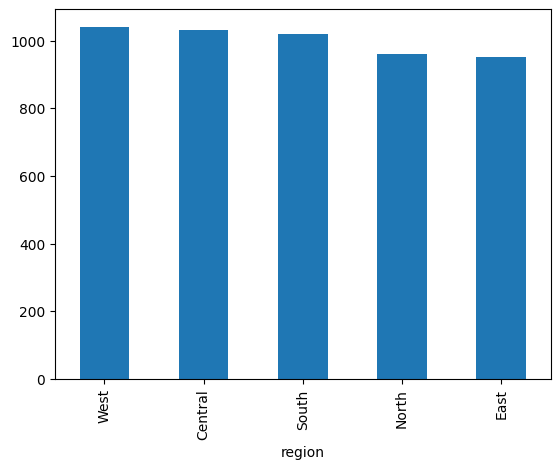

In [56]:
df['region'].value_counts().plot.bar()

In [61]:
df['signup_date'].head()

0   2022-08-30
1   2023-02-03
2   2024-04-13
3   2023-10-08
4   2025-06-18
Name: signup_date, dtype: datetime64[ns]

In [58]:
df['signup_date'] = pd.to_datetime(df['signup_date'])

In [ ]:
df['signup_date'].hist()

5000

In [64]:
df['signup_date'].min(), df['signup_date'].max()


(Timestamp('2020-07-31 00:00:00'), Timestamp('2025-07-31 00:00:00'))

In [66]:
df['signup_month'] = df['signup_date'].dt.to_period('M')
# df['signup_month'].value_counts().sort_index().plot(kind='bar')


In [67]:
df['signup_month']

0       2022-08
1       2023-02
2       2024-04
3       2023-10
4       2025-06
         ...   
4995    2023-03
4996    2024-11
4997    2022-07
4998    2021-07
4999    2021-06
Name: signup_month, Length: 5000, dtype: period[M]

In [69]:
df_label = pd.read_csv("Dataset_customer360/labels.csv")
df_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  5000 non-null   object 
 1   churn        5000 non-null   int64  
 2   ltv          5000 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 117.3+ KB


In [112]:
print(df_label['ltv'].median())

print(df_label['ltv'].mean())
df_label['ltv'].quantile([0.95, 0.99, 0.999])
# df_label['ltv'].max()


8531.165
8568.55132


0.950    10550.47700
0.990    11446.47010
0.999    12644.01038
Name: ltv, dtype: float64

In [80]:
df_label['ltv'].isnull().any()
# df_label['ltv'].isna().any()


np.False_

<Axes: >

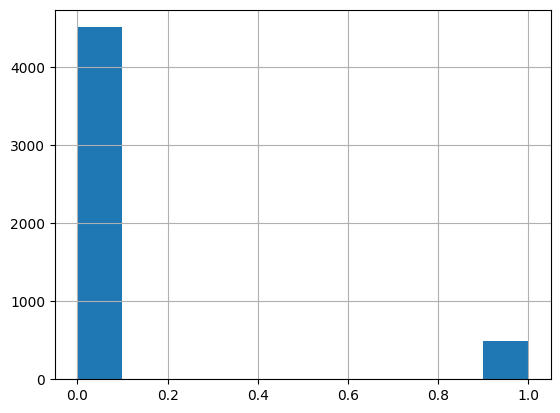

In [83]:
df_label['churn'].hist(bins=10)


In [84]:
df_label['ltv'].value_counts()

ltv
9051.81     3
8423.65     2
6872.88     2
6671.11     2
8106.75     2
           ..
8589.65     1
8383.61     1
7922.28     1
10541.16    1
8870.37     1
Name: count, Length: 4962, dtype: int64

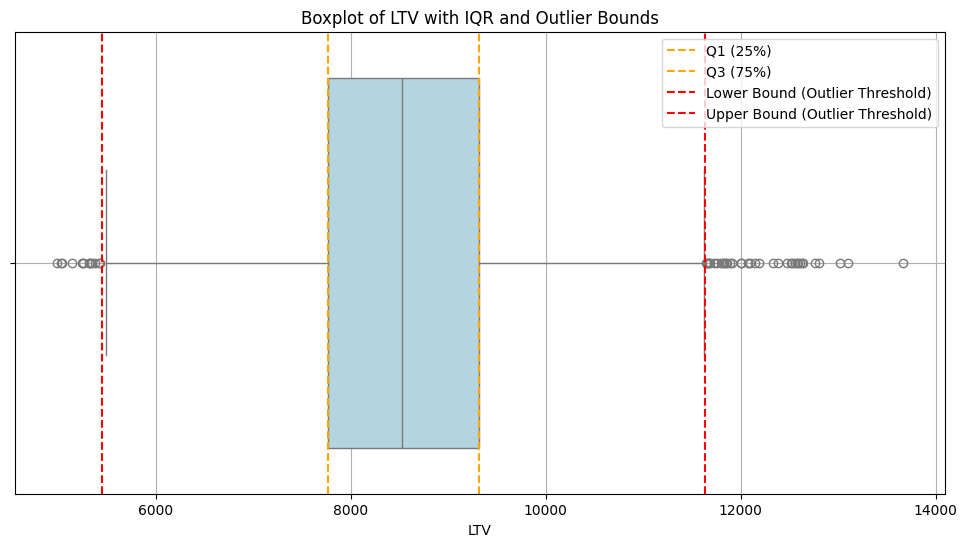

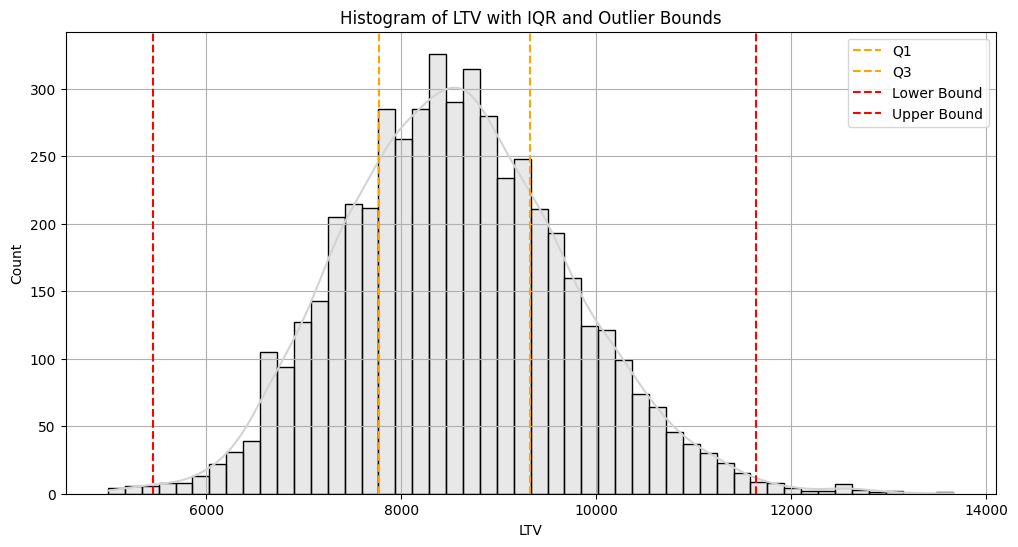

In [113]:
# # df_label['ltv'].hist(bins=100)

# # df_label['ltv'].plot.kde()
# plt.boxplot(df_label['ltv'])
# # fig = plt.figure(figsize =(20, 20))
# plt.show()

# # sns.histplot(df_label['ltv'], bins=50)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate IQR components
Q1 = df_label['ltv'].quantile(0.25)
Q3 = df_label['ltv'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Prepare figure
plt.figure(figsize=(12, 6))

# 1. Boxplot
sns.boxplot(x=df_label['ltv'], color='lightblue')
plt.axvline(Q1, color='orange', linestyle='--', label='Q1 (25%)')
plt.axvline(Q3, color='orange', linestyle='--', label='Q3 (75%)')
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound (Outlier Threshold)')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound (Outlier Threshold)')

plt.title('Boxplot of LTV with IQR and Outlier Bounds')
plt.xlabel('LTV')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 6))
sns.histplot(df_label['ltv'], bins=50, kde=True, color='lightgrey')

plt.axvline(Q1, color='orange', linestyle='--', label='Q1')
plt.axvline(Q3, color='orange', linestyle='--', label='Q3')
plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='red', linestyle='--', label='Upper Bound')

plt.title('Histogram of LTV with IQR and Outlier Bounds')
plt.xlabel('LTV')
plt.legend()
plt.grid(True)
plt.show()


<Axes: ylabel='ltv'>

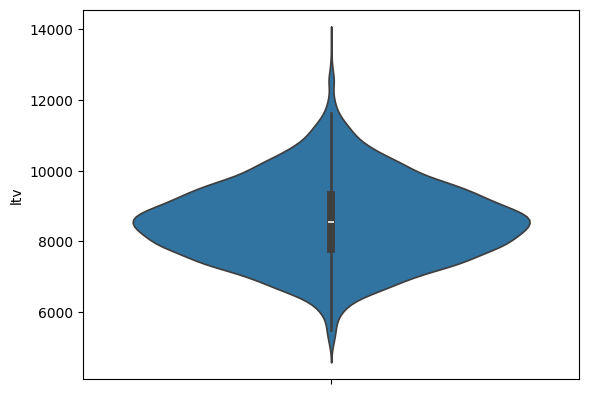

In [114]:
sns.violinplot(df_label['ltv'])


In [99]:
df_label['churn'].value_counts()

churn
0    4515
1     485
Name: count, dtype: int64

In [100]:
485/4315

0.11239860950173812

In [121]:
df_int = pd.read_csv("Dataset_customer360/interactions.csv")
df_int.head()
# df_int.describe()
# df_int.info()
# df_int['ticket_count'].max()


,customer_id,ticket_count,complaint_count,avg_resolution_time,satisfaction_score
0,CUST00000,1,1,3.35,3.27
1,CUST00001,2,0,2.24,3.81
2,CUST00002,3,2,3.29,3.40
3,CUST00003,2,1,1.21,4.29
4,CUST00004,0,0,2.73,4.21


<Axes: >

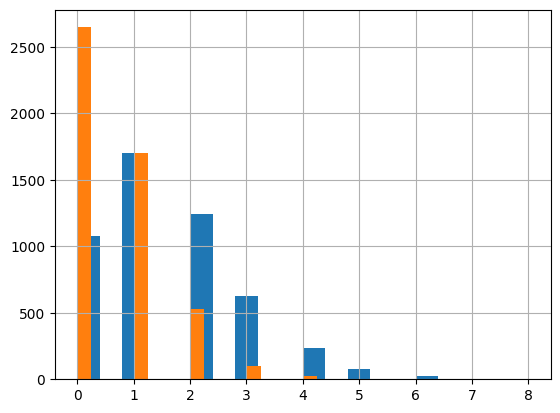

In [126]:
df_int['ticket_count'].hist(bins=20)
df_int['complaint_count'].hist(bins=20)


<Axes: >

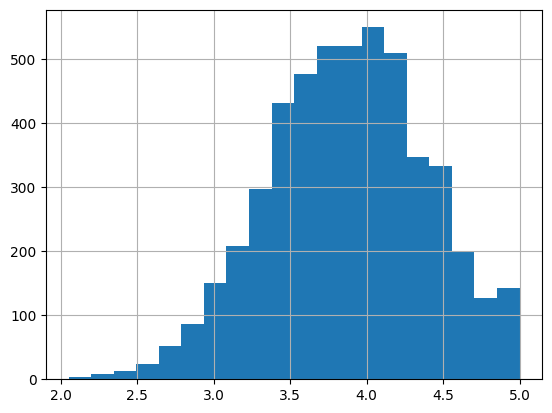

In [127]:
df_int['satisfaction_score'].hist(bins=20)

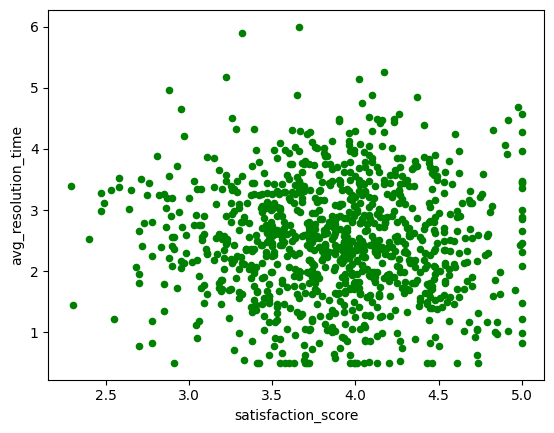

In [143]:
sample = df_int.sample(1000)

sample.plot.scatter(x='satisfaction_score', y='avg_resolution_time',c=['green'])
# sample.plot.scatter(x='complaint_count', y='satisfaction_score')
import seaborn as sns
# sns.lmplot(data=sample, x='complaint_count', y='satisfaction_score', logistic=False)


plt.show()

Text(0, 0.5, 'Avg Satisfaction Score')

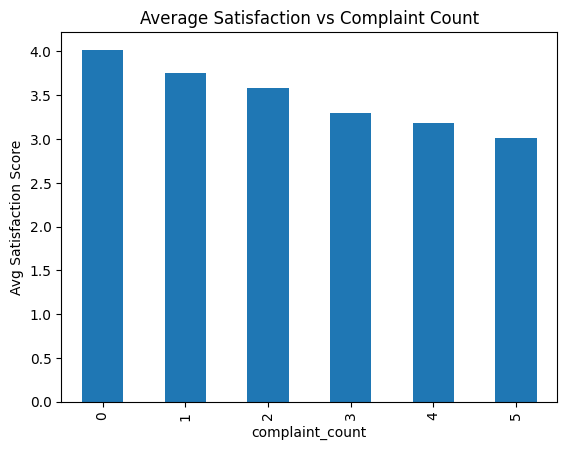

In [142]:
sample.groupby('complaint_count')['satisfaction_score'].mean().plot(kind='bar')
plt.title('Average Satisfaction vs Complaint Count')
plt.ylabel('Avg Satisfaction Score')


In [144]:
camp = pd.read_csv("Dataset_customer360/campaigns.csv")
camp.head()

,customer_id,open_rate,click_rate,purchase_rate,unsubscribed
0,CUST00000,0.19,0.08,0.03,0
1,CUST00001,0.12,0.05,0.02,0
2,CUST00002,0.15,0.08,0.04,0
3,CUST00003,0.32,0.14,0.05,0
4,CUST00004,0.05,0.03,0.01,0


In [146]:
camp.info()
camp.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    5000 non-null   object 
 1   open_rate      5000 non-null   float64
 2   click_rate     5000 non-null   float64
 3   purchase_rate  5000 non-null   float64
 4   unsubscribed   5000 non-null   int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 195.4+ KB


,open_rate,click_rate,purchase_rate,unsubscribed
count,5000.000000,5000.000000,5000.000000,5000.00000
mean,0.291140,0.115544,0.063472,0.04700
std,0.163539,0.075676,0.046563,0.21166
min,0.010000,0.000000,0.000000,0.00000
25%,0.160000,0.060000,0.030000,0.00000
50%,0.270000,0.100000,0.050000,0.00000
75%,0.400000,0.160000,0.090000,0.00000
max,0.920000,0.460000,0.330000,1.00000


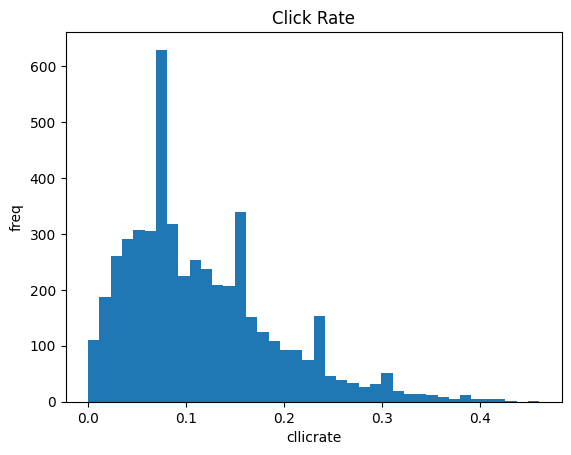

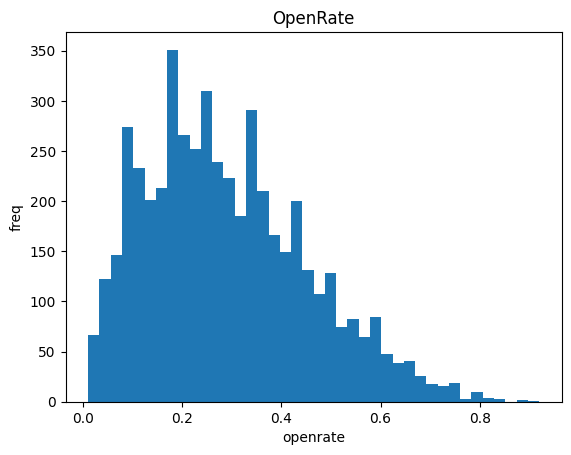

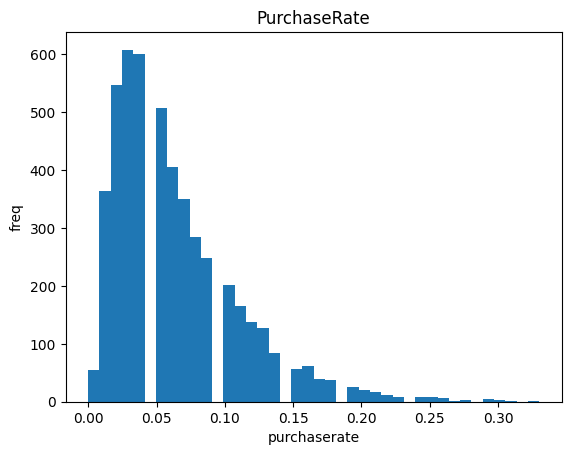

In [154]:
plt.hist(x=camp['click_rate'],bins=40)
plt.title("Click Rate")
plt.xlabel("cllicrate")
plt.ylabel("freq")
plt.show()

plt.hist(x=camp['open_rate'],bins=40)
plt.title("OpenRate")
plt.xlabel("openrate")
plt.ylabel("freq")
plt.show()

plt.hist(x=camp['purchase_rate'],bins=40)
plt.title("PurchaseRate")
plt.xlabel("purchaserate")
plt.ylabel("freq")
plt.show()

In [155]:
0.063472/0.29

0.2188689655172414

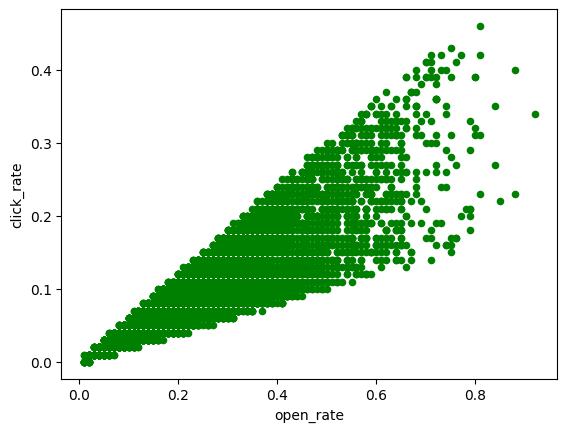

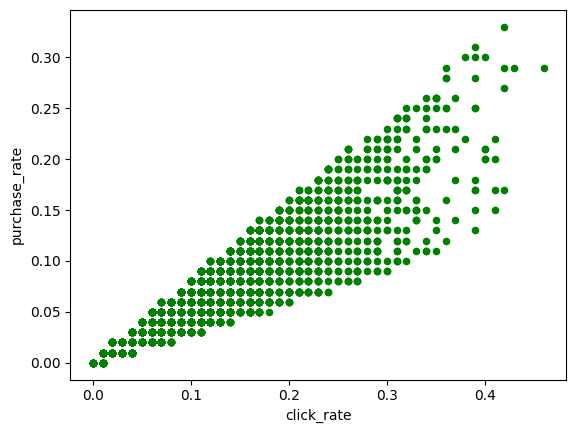

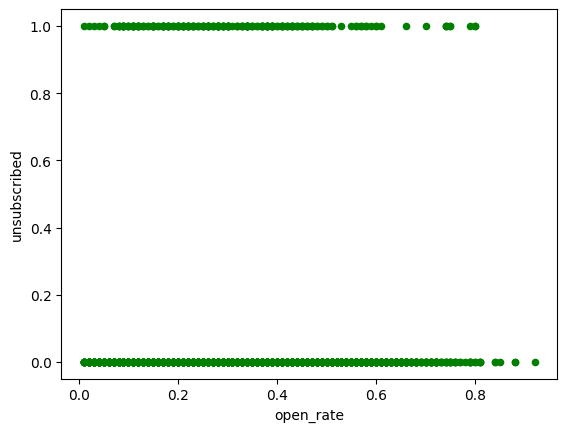

In [ ]:
# sample = camp.sample(1000)

camp.plot.scatter(x='open_rate', y='click_rate',c=['green'])
camp.plot.scatter(x='click_rate', y='purchase_rate',c=['green'])


# sample.plot.scatter(x='complaint_count', y='satisfaction_score')
import seaborn as sns
# sns.lmplot(data=sample, x='complaint_count', y='satisfaction_score', logistic=False)


# plt.show()

<Axes: ylabel='Frequency'>

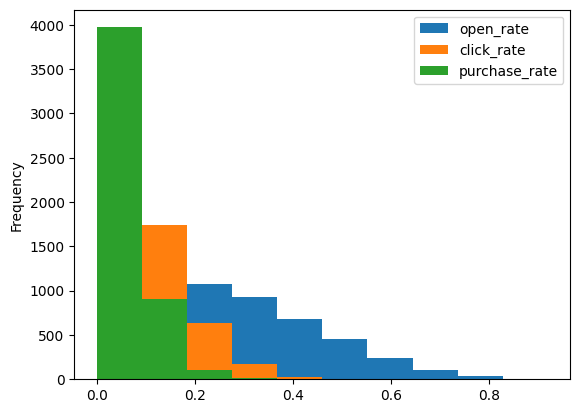

In [161]:
camp.plot.hist(x='unsubscribed',bins=10)


(array([4765.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         235.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

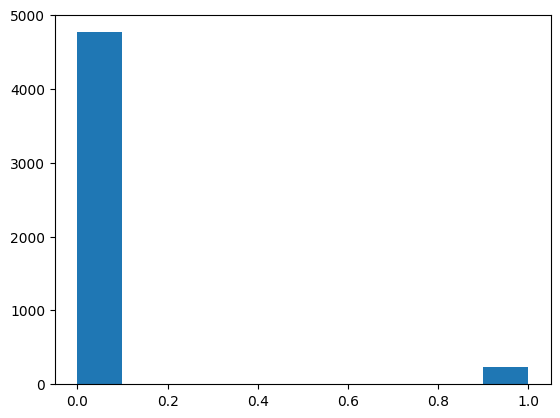

In [166]:
plt.hist(x=camp['unsubscribed'],bins=10)

In [167]:
0.04/0.29

0.13793103448275865

In [185]:
df_cus = pd.read_csv("Dataset_customer360/customers.csv")
df_camp = pd.read_csv("Dataset_customer360/campaigns.csv")
df_int = pd.read_csv("Dataset_customer360/interactions.csv")
df_lab = pd.read_csv("Dataset_customer360/labels.csv")



df_cus_int = pd.merge(df_cus, df_int, on='customer_id')

In [186]:
df_cus_int_camp = pd.merge(df_cus_int, df_camp, on='customer_id')

In [187]:
df_cus_int_camp_lab = pd.merge(df_cus_int_camp, df_lab, on='customer_id')

In [177]:
first_column_name = df_cus_int_camp_lab.columns[0]

# Drop the first column
df_dropped = df_cus_int_camp_lab.drop(columns=[first_column_name])

In [183]:
df_cus_int_camp_lab.rename(columns={ df.columns[0]: "s.no" }, inplace = True)



In [189]:
df_cus_int_camp_lab.to_csv("merged_cus360.csv")

In [ ]:
df_final = pd.read_csv("merged_cus360.csv")

In [41]:
first_column_name = df_final.columns[0]
df_final = df_final.drop(columns=[first_column_name])

In [200]:
df_final.corr(numeric_only=True)

,age,income,ticket_count,complaint_count,avg_resolution_time,satisfaction_score,open_rate,click_rate,purchase_rate,unsubscribed,churn,ltv
age,1.000000,-0.011050,0.006746,-0.005217,0.002368,-0.016651,-0.025600,-0.025564,-0.018676,0.019050,-0.015485,-0.013539
income,-0.011050,1.000000,0.017953,0.029985,0.007054,-0.004151,0.016203,0.008446,-0.001112,0.006153,-0.013453,-0.003134
ticket_count,0.006746,0.017953,1.000000,0.641983,-0.032824,-0.202045,0.012149,0.011531,0.017385,-0.012405,0.281560,-0.001810
complaint_count,-0.005217,0.029985,0.641983,1.000000,-0.014816,-0.302237,-0.006863,-0.005753,0.000341,-0.018165,0.422557,-0.000830
avg_resolution_time,0.002368,0.007054,-0.032824,-0.014816,1.000000,-0.011690,-0.008315,-0.010846,-0.010543,-0.007903,0.008308,0.011153
satisfaction_score,-0.016651,-0.004151,-0.202045,-0.302237,-0.011690,1.000000,0.006617,-0.010717,-0.016802,-0.011529,-0.380819,0.009927
open_rate,-0.025600,0.016203,0.012149,-0.006863,-0.008315,0.006617,1.000000,0.862220,0.777006,0.015673,-0.046917,0.018736
click_rate,-0.025564,0.008446,0.011531,-0.005753,-0.010846,-0.010717,0.862220,1.000000,0.902221,0.017823,-0.029014,0.012485
purchase_rate,-0.018676,-0.001112,0.017385,0.000341,-0.010543,-0.016802,0.777006,0.902221,1.000000,0.014494,-0.022990,0.006409
unsubscribed,0.019050,0.006153,-0.012405,-0.018165,-0.007903,-0.011529,0.015673,0.017823,0.014494,1.000000,0.003848,0.004377


**PHASE2**

In [42]:
df_final = pd.read_csv("merged_cus360.csv")
first_column_name = df_final.columns[0]

# Drop the first column
df_final = df_final.drop(columns=[first_column_name])

In [5]:
df_final.isnull().sum()

customer_id            0
age                    0
gender                 0
region                 0
income                 0
signup_date            0
ticket_count           0
complaint_count        0
avg_resolution_time    0
satisfaction_score     0
open_rate              0
click_rate             0
purchase_rate          0
unsubscribed           0
churn                  0
ltv                    0
dtype: int64

In [ ]:
import os

list = []

for idx,i in enumerate(os.listdir("Dataset_customer360")):
    file = i.split("_")
    if len(file)>1:
        if "part" in file[1]:
            # print(file[1])
            fill,idx = file[1].split("t")
            print(idx)
            idx = int(idx)
            list.append(idx)
    # break

12
6
11
10
3
16
15
13
2
9
20
5
8
18
17
4
7
1
19
14


In [22]:
list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [34]:
import pandas as pd
import glob
import os
import re

# Set your folder path
folder_path = "Dataset_customer360"
pattern = os.path.join(folder_path, "transactions_part*.csv")

# Extract number from filename like transactions_part5_of20.csv
def extract_part_number(filename):
    match = re.search(r'part(\d+)_of', os.path.basename(filename))
    return int(match.group(1)) if match else float('inf')  # ensure unsorted files go to the end

# Get all CSV files and sort by part number
all_files = sorted(glob.glob(pattern), key=extract_part_number)

# Check sorted order (optional)
# print(all_files)

# Concatenate in order
df_list = [pd.read_csv(file) for file in all_files]
merged_df = pd.concat(df_list, ignore_index=True)

print("Merged shape:", merged_df.shape)


Merged shape: (503816, 4)


In [37]:
merged_df.to_csv("all_trans.csv")

In [40]:
df_final = pd.read_csv("merged_cus360.csv")
df_final.head()


,Unnamed: 0,customer_id,age,gender,region,income,signup_date,ticket_count,complaint_count,avg_resolution_time,satisfaction_score,open_rate,click_rate,purchase_rate,unsubscribed,churn,ltv
0,0,CUST00000,56,Male,North,20089.18,2022-08-30,1,1,3.35,3.27,0.19,0.08,0.03,0,0,10743.89
1,1,CUST00001,69,Male,Central,55869.83,2023-02-03,2,0,2.24,3.81,0.12,0.05,0.02,0,0,7642.60
2,2,CUST00002,46,Male,East,24074.44,2024-04-13,3,2,3.29,3.40,0.15,0.08,0.04,0,1,10474.98
3,3,CUST00003,32,Female,East,22368.14,2023-10-08,2,1,1.21,4.29,0.32,0.14,0.05,0,0,10153.26
4,4,CUST00004,60,Male,South,42868.50,2025-06-18,0,0,2.73,4.21,0.05,0.03,0.01,0,0,8910.84


In [43]:
df_final.head()

,customer_id,age,gender,region,income,signup_date,ticket_count,complaint_count,avg_resolution_time,satisfaction_score,open_rate,click_rate,purchase_rate,unsubscribed,churn,ltv
0,CUST00000,56,Male,North,20089.18,2022-08-30,1,1,3.35,3.27,0.19,0.08,0.03,0,0,10743.89
1,CUST00001,69,Male,Central,55869.83,2023-02-03,2,0,2.24,3.81,0.12,0.05,0.02,0,0,7642.60
2,CUST00002,46,Male,East,24074.44,2024-04-13,3,2,3.29,3.40,0.15,0.08,0.04,0,1,10474.98
3,CUST00003,32,Female,East,22368.14,2023-10-08,2,1,1.21,4.29,0.32,0.14,0.05,0,0,10153.26
4,CUST00004,60,Male,South,42868.50,2025-06-18,0,0,2.73,4.21,0.05,0.03,0.01,0,0,8910.84


In [47]:
df_final['gender'].value_counts(normalize=True) #only 0.03% is other so can be dropped
df_final = df_final[df_final['gender'] != "Other"]

In [48]:
df_final.shape

(4813, 16)

In [49]:
df_final = pd.get_dummies(df_final,columns=['gender', 'region'])
df_final.shape

(4813, 21)

In [50]:
df_final.head()

,customer_id,age,income,signup_date,ticket_count,complaint_count,avg_resolution_time,satisfaction_score,open_rate,click_rate,...,unsubscribed,churn,ltv,gender_Female,gender_Male,region_Central,region_East,region_North,region_South,region_West
0,CUST00000,56,20089.18,2022-08-30,1,1,3.35,3.27,0.19,0.08,...,0,0,10743.89,False,True,False,False,True,False,False
1,CUST00001,69,55869.83,2023-02-03,2,0,2.24,3.81,0.12,0.05,...,0,0,7642.60,False,True,True,False,False,False,False
2,CUST00002,46,24074.44,2024-04-13,3,2,3.29,3.40,0.15,0.08,...,0,1,10474.98,False,True,False,True,False,False,False
3,CUST00003,32,22368.14,2023-10-08,2,1,1.21,4.29,0.32,0.14,...,0,0,10153.26,True,False,False,True,False,False,False
4,CUST00004,60,42868.50,2025-06-18,0,0,2.73,4.21,0.05,0.03,...,0,0,8910.84,False,True,False,False,False,True,False


In [51]:
df_final.select_dtypes(include='number').describe()


,age,income,ticket_count,complaint_count,avg_resolution_time,satisfaction_score,open_rate,click_rate,purchase_rate,unsubscribed,churn,ltv
count,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000,4813.000000
mean,46.126532,24842.150177,1.521296,0.629545,2.481330,3.875770,0.291635,0.115782,0.063607,0.046748,0.097029,8565.142360
std,16.327526,13245.477860,1.240347,0.790435,0.974519,0.518338,0.163756,0.075817,0.046678,0.211121,0.296028,1160.072809
min,18.000000,4447.600000,0.000000,0.000000,0.500000,2.050000,0.010000,0.000000,0.000000,0.000000,0.000000,4990.980000
25%,32.000000,15477.960000,1.000000,0.000000,1.790000,3.520000,0.160000,0.060000,0.030000,0.000000,0.000000,7775.010000
50%,46.000000,21894.780000,1.000000,0.000000,2.470000,3.890000,0.270000,0.100000,0.050000,0.000000,0.000000,8523.110000
75%,60.000000,30582.890000,2.000000,1.000000,3.150000,4.230000,0.400000,0.160000,0.090000,0.000000,0.000000,9317.500000
max,74.000000,109010.460000,8.000000,5.000000,6.000000,5.000000,0.920000,0.460000,0.330000,1.000000,1.000000,13661.230000


<Axes: >

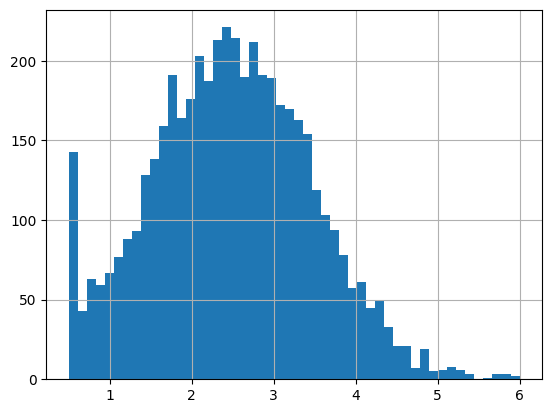

In [59]:
# df_final['income'].hist(bins=50)
# df_final['age'].hist(bins=50) # 20 to 70
df_final['avg_resolution_time'].hist(bins=50)

<Axes: >

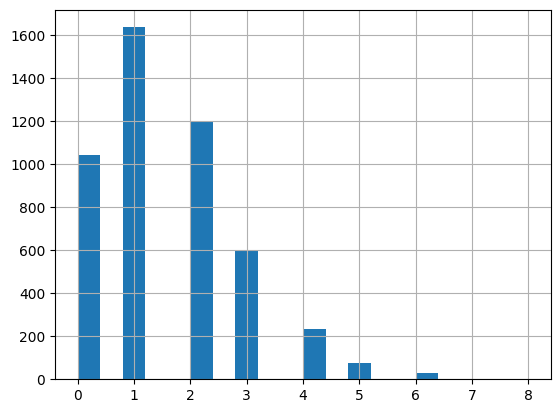

In [62]:
df_final['ticket_count'].hist(bins=20)

In [64]:
df_final['log_income'] = np.log1p(df_final['income'])


<Axes: >

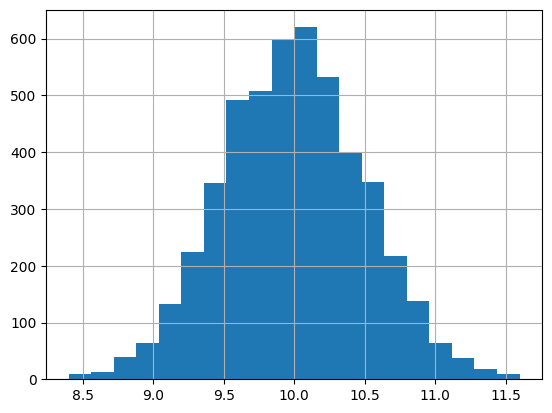

In [65]:
df_final['log_income'].hist(bins=20)

<Axes: >

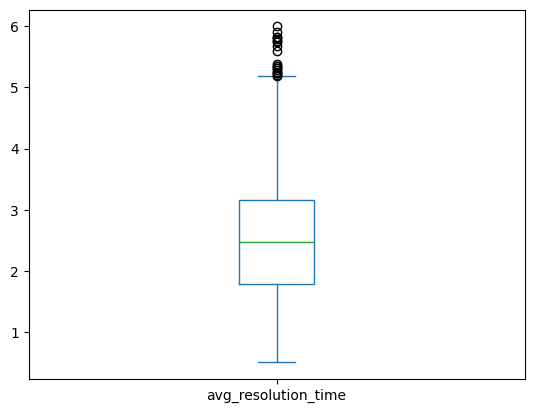

In [66]:
df_final['avg_resolution_time'].describe()
df_final['avg_resolution_time'].plot(kind='box')

In [67]:
df_final['avg_resolution_time'].quantile([0.95, 0.99])


0.95    4.1000
0.99    4.8288
Name: avg_resolution_time, dtype: float64

In [68]:
df_final['avg_resolution_time'] = df_final['avg_resolution_time'].clip(upper=4.83)


In [69]:
df_final['signup_date'] = pd.to_datetime(df_final['signup_date'])


In [71]:
ref_date = df_final['signup_date'].max()
print(ref_date)

2025-07-31 00:00:00


In [72]:
df_final['tenure_days'] = (ref_date - df_final['signup_date']).dt.days


In [77]:
print(df_final['tenure_days'].max())

print(df_final['tenure_days'].min())

print(df_final['signup_date'].max())

print(df_final['signup_date'].min())

1826
0
2025-07-31 00:00:00
2020-07-31 00:00:00


In [78]:
df_final['tenure_group'] = pd.cut(df_final['tenure_days'],bins=[-1, 180, 365, 730, 1095, 1460, 1826],labels=['0–6mo', '6–12mo', '1–2y', '2–3y', '3–4y', '4–5y'])


In [82]:
df_final['tenure_group'].value_counts().sort_index()


tenure_group
0–6mo     473
6–12mo    484
1–2y      985
2–3y      999
3–4y      921
4–5y      951
Name: count, dtype: int64

In [84]:
trans_df = pd.read_csv("all_trans.csv")
first_column_name = trans_df.columns[0]

# Drop the first column
trans_df = trans_df.drop(columns=[first_column_name])

In [85]:
trans_df.sample(5)

,customer_id,txn_date,amount,category
438421,CUST04353,2023-01-29,18.46,Clothing
296358,CUST02940,2025-07-30,108.01,Clothing
70072,CUST00692,2022-09-25,22.24,Clothing
130134,CUST01287,2024-07-31,5.09,Clothing
70113,CUST00692,2024-05-19,485.02,Grocery


In [86]:
trans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503816 entries, 0 to 503815
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   customer_id  503816 non-null  object 
 1   txn_date     503816 non-null  object 
 2   amount       503816 non-null  float64
 3   category     503816 non-null  object 
dtypes: float64(1), object(3)
memory usage: 15.4+ MB


In [87]:
trans_df['txn_date'] = pd.to_datetime(trans_df['txn_date'])

In [88]:
trans_df['txn_date'].max()

Timestamp('2025-08-01 00:00:00')

In [89]:
trans_df['txn_date'].min()

Timestamp('2020-08-02 00:00:00')

In [90]:
ref_date = pd.Timestamp("2025-08-02")
print(ref_date)

2025-08-02 00:00:00


In [95]:
ref_date - trans_df['txn_date']

0         534 days
1        1041 days
2         416 days
3         925 days
4         975 days
            ...   
503811    350 days
503812    238 days
503813    836 days
503814    932 days
503815    914 days
Name: txn_date, Length: 503816, dtype: timedelta64[ns]

In [96]:
trans_df['recency_date'] = ref_date - trans_df['txn_date']

In [99]:
trans_df['recency_date'].min()

Timedelta('1 days 00:00:00')

In [102]:
recency_df = trans_df.groupby('customer_id')['recency_date'].min().dt.days.reset_index()


In [103]:
recency_df.rename(columns={'recency_date': 'recency_days'}, inplace=True)


In [119]:
recency_df.head()

,customer_id,recency_days
0,CUST00000,18
1,CUST00001,9
2,CUST00002,13
3,CUST00003,2
4,CUST00004,1


In [105]:
freq_df = trans_df.groupby('customer_id').size().reset_index(name='txn_count')


In [106]:
monetary_df = trans_df.groupby('customer_id')['amount'].sum().reset_index(name='monetary_total')

In [108]:
avg_txn = trans_df.groupby('customer_id')['amount'].mean().reset_index(name='avg_txn_amount')


In [113]:
print(freq_df.max())
print(freq_df.min())

customer_id    CUST04999
txn_count            138
dtype: object
customer_id    CUST00000
txn_count             61
dtype: object


In [114]:
print(monetary_df.max())
print(monetary_df.min())

customer_id       CUST04999
monetary_total     13753.07
dtype: object
customer_id       CUST00000
monetary_total      4948.34
dtype: object


In [115]:
one_txn = freq_df[freq_df['txn_count']==1]
print(one_txn)

Empty DataFrame
Columns: [customer_id, txn_count]
Index: []


In [116]:
threshold = monetary_df['monetary_total'].quantile(0.95)
top_5_percent_spenders = monetary_df[monetary_df['monetary_total'] >= threshold]

print(top_5_percent_spenders)


     customer_id  monetary_total
0      CUST00000        10761.49
15     CUST00015        11215.85
37     CUST00037        11190.99
45     CUST00045        11472.42
71     CUST00071        12623.26
...          ...             ...
4862   CUST04862        11192.80
4867   CUST04867        11953.30
4897   CUST04897        11263.11
4898   CUST04898        11283.65
4948   CUST04948        10695.69

[250 rows x 2 columns]


In [117]:
cat_count = trans_df.groupby('customer_id')['category'].nunique().reset_index(name='category_count') 


In [118]:
print(cat_count.max())
print(cat_count.min())

customer_id       CUST04999
category_count            5
dtype: object
customer_id       CUST00000
category_count            5
dtype: object


In [122]:
rfm_df = recency_df.merge(freq_df, on='customer_id',how='left').merge(monetary_df, on='customer_id',how='left').merge(avg_txn,on='customer_id',how='left')

In [123]:
rfm_df.head()

,customer_id,recency_days,txn_count,monetary_total,avg_txn_amount
0,CUST00000,18,114,10761.49,94.399035
1,CUST00001,9,102,7597.20,74.482353
2,CUST00002,13,118,10498.94,88.974068
3,CUST00003,2,121,10238.30,84.614050
4,CUST00004,1,93,9056.64,97.383226


In [124]:
rfm_df.isnull().sum()

customer_id       0
recency_days      0
txn_count         0
monetary_total    0
avg_txn_amount    0
dtype: int64

In [128]:
len(df_final.columns)

24

In [131]:
corr_matrix = df_final.corr(numeric_only=True)

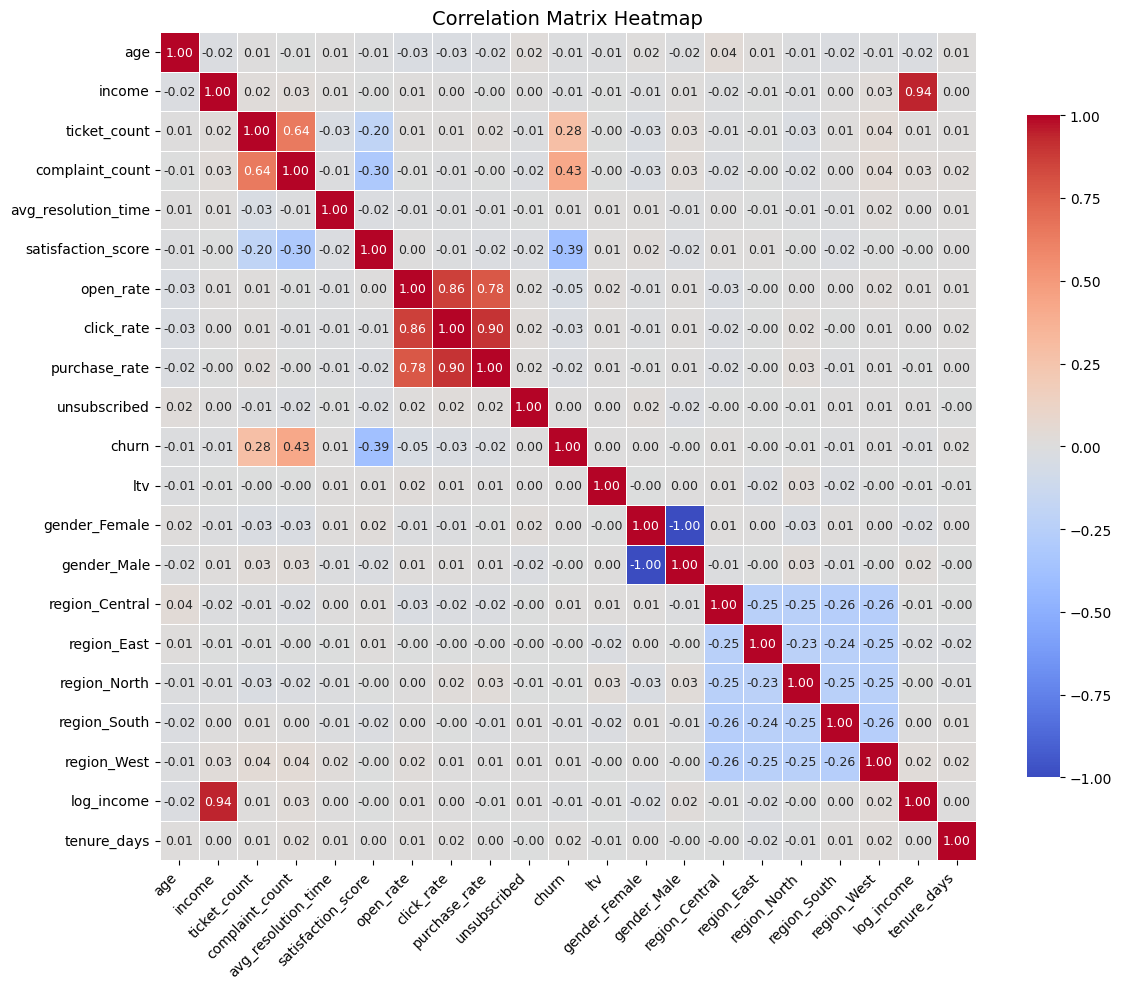

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))  # Increase figure size

sns.heatmap(
    corr_matrix,           # your correlation DataFrame
    annot=True,            # show values inside boxes
    fmt=".2f",             # format values to 2 decimal places
    cmap='coolwarm',       # color gradient
    linewidths=0.5,        # lines between cells
    annot_kws={"size": 9}, # smaller font for annotations
    cbar_kws={"shrink": 0.8}  # shrink color bar
)

plt.xticks(rotation=45, ha='right')  # tilt x labels for space
plt.yticks(rotation=0)               # keep y labels horizontal
plt.title('Correlation Matrix Heatmap', fontsize=14)
plt.tight_layout()                   # auto-adjust layout
plt.show()


In [135]:
df_final.drop('ticket_count', axis=1, inplace=True)


In [286]:
X = df_final.drop(columns=['customer_id', 'ltv', 'churn','signup_date'])  # feature set
y = df_final['churn']      
X = pd.get_dummies(X, columns=['tenure_group'], drop_first=True)# binary target

# print(X.dtypes)


from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)


feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

In [287]:
 df_final.drop(columns=['customer_id', 'ltv', 'churn','signup_date'])  # feature set
# 

,age,income,complaint_count,avg_resolution_time,satisfaction_score,open_rate,click_rate,purchase_rate,unsubscribed,gender_Female,...,region_Central,region_East,region_North,region_South,region_West,log_income,tenure_days,tenure_group,ltv_log,cluster
0,56,20089.18,1,3.35,3.27,0.19,0.08,0.03,0,False,...,False,False,True,False,False,9.907986,1066,2–3y,9.282186,0
1,69,55869.83,0,2.24,3.81,0.12,0.05,0.02,0,False,...,True,False,False,False,False,10.930798,909,2–3y,8.941624,0
2,46,24074.44,2,3.29,3.40,0.15,0.08,0.04,0,False,...,False,True,False,False,False,10.088948,474,1–2y,9.256840,0
3,32,22368.14,1,1.21,4.29,0.32,0.14,0.05,0,True,...,False,True,False,False,False,10.015438,662,1–2y,9.225649,1
4,60,42868.50,0,2.73,4.21,0.05,0.03,0.01,0,False,...,False,False,False,True,False,10.665916,43,0–6mo,9.095136,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,67,44214.19,0,2.11,3.36,0.19,0.08,0.04,0,False,...,False,True,False,False,False,10.696824,872,2–3y,9.083538,0
4996,39,42064.12,1,1.92,4.23,0.60,0.26,0.17,0,False,...,False,False,True,False,False,10.646974,270,6–12mo,8.964450,2
4997,46,9136.52,0,1.72,4.24,0.08,0.02,0.01,0,False,...,True,False,False,False,False,9.120144,1118,3–4y,9.010650,0
4998,39,54113.73,0,2.33,3.80,0.35,0.17,0.13,0,True,...,False,False,True,False,False,10.898862,1487,4–5y,8.862498,2


In [288]:
# Sort by importance and take top 15 features
top_features = feature_importance.sort_values(by='importance', ascending=False).head(15)

# Get their names as a list
top_feature_names = top_features['feature'].tolist()


print(top_feature_names)

['complaint_count', 'satisfaction_score', 'tenure_days', 'ltv_log', 'log_income', 'avg_resolution_time', 'income', 'open_rate', 'age', 'click_rate', 'purchase_rate', 'cluster', 'region_East', 'region_Central', 'region_North']


In [289]:
df_cleaned = X[top_feature_names]


In [290]:
df_cleaned = df_cleaned.drop(columns='income')

In [291]:
df_cleaned.columns

Index(['complaint_count', 'satisfaction_score', 'tenure_days', 'ltv_log',
       'log_income', 'avg_resolution_time', 'open_rate', 'age', 'click_rate',
       'purchase_rate', 'cluster', 'region_East', 'region_Central',
       'region_North'],
      dtype='object')

In [292]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_cleaned)


In [293]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

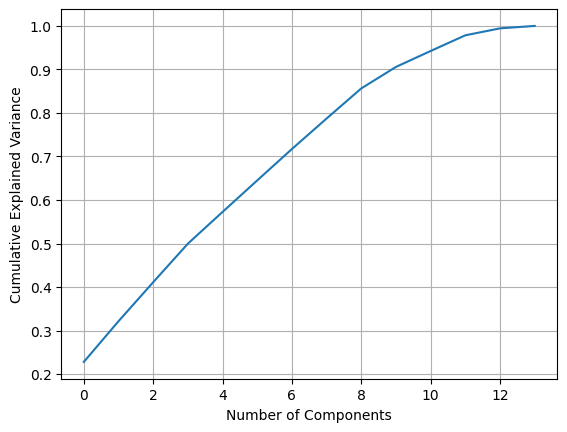

In [294]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()

**PHASE4**

In [295]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X and y already defined
scaler = StandardScaler()

# Scale only the features (X)
X = scaler.fit_transform(X)

# DO NOT scale y
# y = scaler.fit_transform(y) ← REMOVE THIS

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


array([[-1.16879931,  0.46872093,  0.29735847, ..., -0.51049745,
         0.9829012 , -0.48286021],
       [-0.12689917, -0.79653641, -0.002392  , ...,  1.95887364,
         0.9829012 , -0.48286021],
       [-0.9179715 ,  1.73397827, -0.83291083, ..., -0.51049745,
         0.9829012 ,  2.07099275],
       ...,
       [ 0.70276205, -0.79653641,  0.39663888, ...,  1.95887364,
         0.9829012 , -0.48286021],
       [-0.14619362, -0.79653641,  1.10114796, ..., -0.51049745,
        -1.01739625, -0.48286021],
       [ 1.0114732 , -0.79653641,  1.12024035, ..., -0.51049745,
         0.9829012 , -0.48286021]])

In [296]:
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())


Train churn rate: 0.09714285714285714
Test churn rate: 0.09657320872274143


In [196]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression()
LR.fit(X_train,y_train)



LogisticRegression()

In [197]:
y_pred = LR.predict(X_test)

Precison is 0.7380952380952381 , Recall is 0.3333333333333333 , F1 score is 0.45925925925925926 , ROC score is 0.6603448275862068


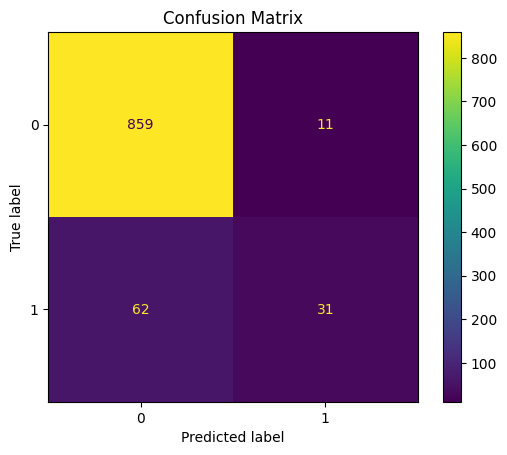

In [198]:
from sklearn.metrics import precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay


p = precision_score(y_test,y_pred)
r = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_pred)

cm = confusion_matrix(y_test,y_pred,labels=LR.classes_)

print(f"Precison is {p} , Recall is {r} , F1 score is {f1} , ROC score is {roc}")


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LR.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [297]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import recall_score
import numpy as np

# 1. Define the base model
rf = RandomForestClassifier(random_state=42)

# 2. Define hyperparameter space
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

# 3. Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,             # Try 20 random combinations
    cv=5,                  # 5-fold cross-validation
    scoring='recall',      # Focus on catching more churners
    verbose=2,
    random_state=42,
    n_jobs=-1              # Use all available cores
)

# 4. Run the search
random_search.fit(X_train, y_train)

# 5. Print best parameters and score
print("Best Recall Score:", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)

# 6. Save the best model
best_rf = random_search.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END class_weight=None, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.7s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.7s
[CV] END class_weight=None, max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.7s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.7s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.7s
[CV] END class_weight=None, max_depth=20, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.7s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.7s
[CV] END class_weight=None, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_

In [299]:
print("Best Parameters:", random_search.best_params_)


Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'class_weight': 'balanced'}


In [298]:
from sklearn.metrics import classification_report

y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89       870
           1       0.34      0.88      0.49        93

    accuracy                           0.83       963
   macro avg       0.66      0.85      0.69       963
weighted avg       0.92      0.83      0.86       963



Precison is 0.34309623430962344 , Recall is 0.8817204301075269 , F1 score is 0.4939759036144578 , ROC score is 0.8506303299962923


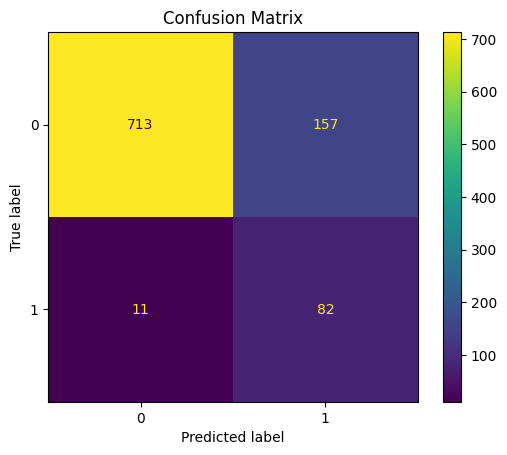

In [300]:
from sklearn.ensemble import RandomForestClassifier

# RF = RandomForestClassifier(n_estimators=100,random_state=42)

# RF.fit(X_train,y_train)
y_pred = best_rf.predict(X_test)

p = precision_score(y_test,y_pred)
r = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_pred)

cm = confusion_matrix(y_test,y_pred,labels=best_rf.classes_)

print(f"Precison is {p} , Recall is {r} , F1 score is {f1} , ROC score is {roc}")


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LR.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

Precison is 0.8076923076923077 , Recall is 0.45161290322580644 , F1 score is 0.5793103448275863 , ROC score is 0.7200593251761217


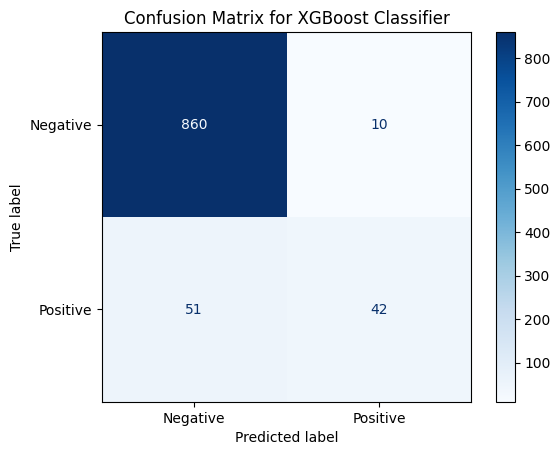

In [210]:
from xgboost import XGBClassifier

clf = XGBClassifier(objective='binary:logistic',  # For binary classification
                        n_estimators=100,
                        learning_rate=0.1,
                        max_depth=4)
clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

p = precision_score(y_test,y_pred)
r = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_pred)

cm = confusion_matrix(y_test,y_pred)

print(f"Precison is {p} , Recall is {r} , F1 score is {f1} , ROC score is {roc}")


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for XGBoost Classifier')
plt.show()

In [212]:
df_final.columns

Index(['customer_id', 'age', 'income', 'signup_date', 'complaint_count',
       'avg_resolution_time', 'satisfaction_score', 'open_rate', 'click_rate',
       'purchase_rate', 'unsubscribed', 'churn', 'ltv', 'gender_Female',
       'gender_Male', 'region_Central', 'region_East', 'region_North',
       'region_South', 'region_West', 'log_income', 'tenure_days',
       'tenure_group'],
      dtype='object')

**REGRESSION**

In [240]:
import numpy as np

df_final['ltv_log'] = np.log1p(df_final['ltv'])

In [254]:
X = df_final.drop(columns=['customer_id', 'ltv', 'churn','signup_date'])  # feature set
y = df_final['ltv_log']      
X = pd.get_dummies(X, columns=['tenure_group'], drop_first=True)# binary target

In [255]:
# top_feature_names

In [256]:
df_reg = X[top_feature_names]


In [257]:
y

0       9.282186
1       8.941624
2       9.256840
3       9.225649
4       9.095136
          ...   
4995    9.083538
4996    8.964450
4997    9.010650
4998    8.862498
4999    9.019624
Name: ltv_log, Length: 4813, dtype: float64

In [258]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X and y already defined
scaler = StandardScaler()

# Scale only the features (X)
X = scaler.fit_transform(X)

# DO NOT scale y
# y = scaler.fit_transform(y) ← REMOVE THIS

# Train/test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y,
    test_size=0.2,
    # stratify=y,
    random_state=42
)


In [259]:
y

0       9.282186
1       8.941624
2       9.256840
3       9.225649
4       9.095136
          ...   
4995    9.083538
4996    8.964450
4997    9.010650
4998    8.862498
4999    9.019624
Name: ltv_log, Length: 4813, dtype: float64

In [247]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

LinReg = LinearRegression()
LinReg.fit(X_train_reg,y_train_reg)


y_pred = LinReg.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg,y_pred)
mse = mean_squared_error(y_test_reg,y_pred)
rmse = root_mean_squared_error(y_test_reg,y_pred)
r2 = r2_score(y_test_reg,y_pred)

print(f"mae is {mae} , mse is {mse} , rmse is {rmse} , r2 score is {r2}")

# cm = confusion_matrix(y_test_reg,y_pred)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LR.classes_)
# disp.plot()
# plt.title("Confusion Matrix")
# plt.show()





mae is 1.7763568394002505e-15 , mse is 3.1554436208840472e-30 , rmse is 1.7763568394002505e-15 , r2 score is 1.0


In [252]:
from sklearn.ensemble import RandomForestRegressor

RFG = RandomForestRegressor(n_estimators=200,random_state=42)
RFG.fit(X_train_reg,y_train_reg)

y_pred = RFG.predict(X_test_reg)

y_pred = np.expm1(y_pred )       # Convert back to original scale
y_test_reg = np.expm1(y_test_reg)        # Convert true values too

mae = mean_absolute_error(y_test_reg,y_pred)
mse = mean_squared_error(y_test_reg,y_pred)
rmse = root_mean_squared_error(y_test_reg,y_pred)
r2 = r2_score(y_test_reg,y_pred)

print(f"mae is {mae} , mse is {mse} , rmse is {rmse} , r2 score is {r2}")

mae is 1.3177390986843953 , mse is 30.063626900278017 , rmse is 5.483030813362078 , r2 score is 0.9999767787096638


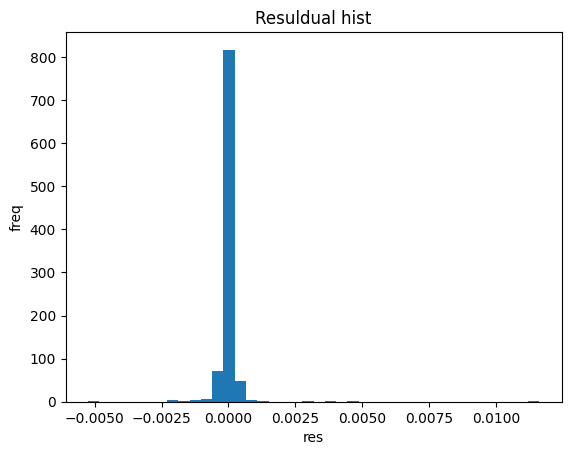

In [249]:
residuals = y_test_reg - y_pred
plt.hist(x=residuals,bins = 40)
plt.title("Resuldual hist")
plt.xlabel("res")
plt.ylabel("freq")
plt.show()

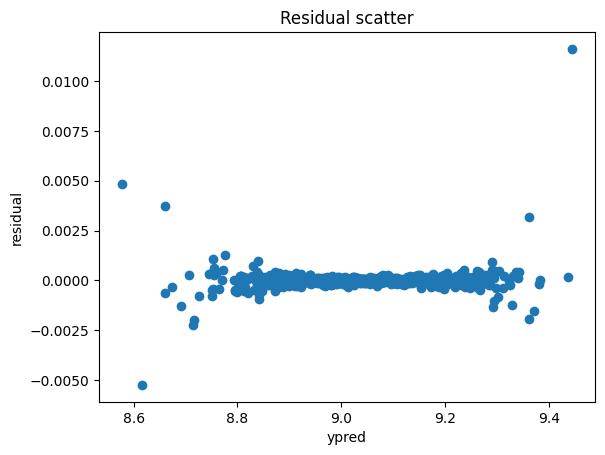

In [250]:
plt.scatter(x=y_pred,y=residuals)
plt.title("Residual scatter")
plt.xlabel("ypred")
plt.ylabel("residual")
plt.show()


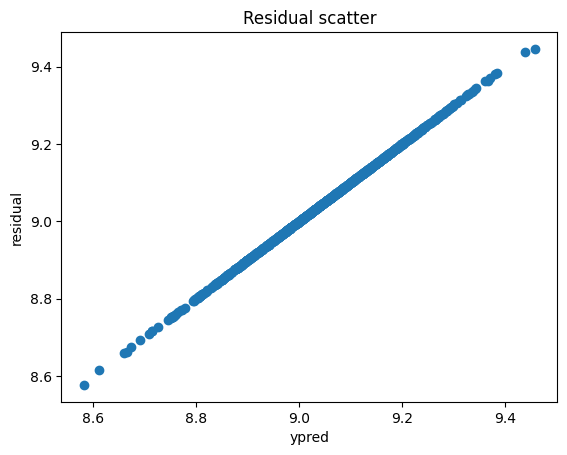

In [251]:
plt.scatter(x=y_test_reg,y=y_pred)
plt.title("Residual scatter")
plt.xlabel("ypred")
plt.ylabel("residual")
plt.show()

In [260]:
from xgboost import XGBRegressor
xgbr = XGBRegressor(n_estimators=200,random_state=42)
xgbr.fit(X_train_reg,y_train_reg)

y_pred = xgbr.predict(X_test_reg)

y_pred = np.expm1(y_pred )       # Convert back to original scale
y_test_reg = np.expm1(y_test_reg)        # Convert true values too

mae = mean_absolute_error(y_test_reg,y_pred)
mse = mean_squared_error(y_test_reg,y_pred)
rmse = root_mean_squared_error(y_test_reg,y_pred)
r2 = r2_score(y_test_reg,y_pred)

print(f"mae is {mae} , mse is {mse} , rmse is {rmse} , r2 score is {r2}")

mae is 9.681048298773234 , mse is 1008.6468082631712 , rmse is 31.759200371910676 , r2 score is 0.9992209163432256


[0.19273336 0.14313535]
Cumulative variance: 0.3358687107884402


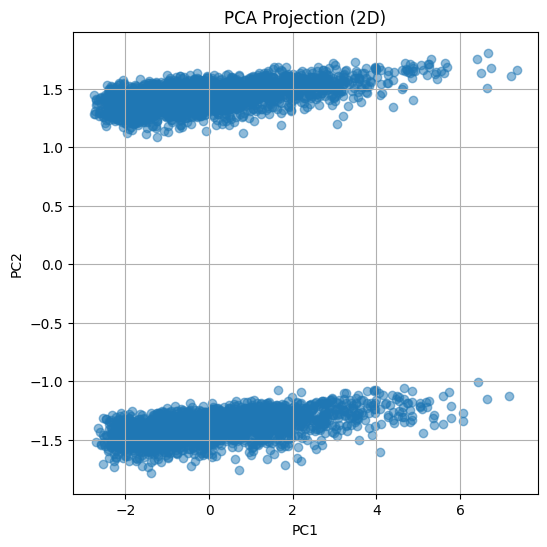

In [264]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)  # You can try 3 later too
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)
print("Cumulative variance:", pca.explained_variance_ratio_.sum())

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2D)")
plt.grid(True)
plt.show()


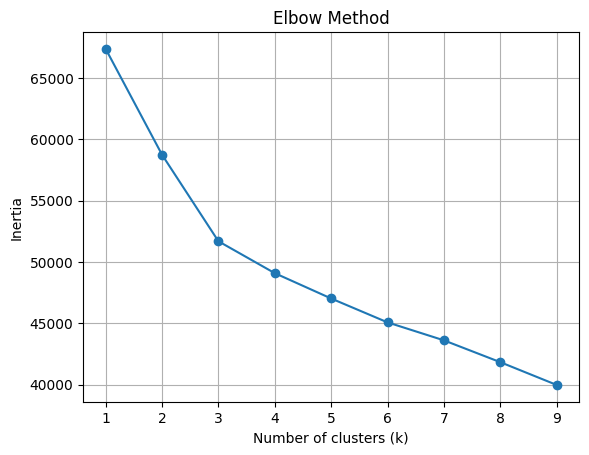

In [265]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()


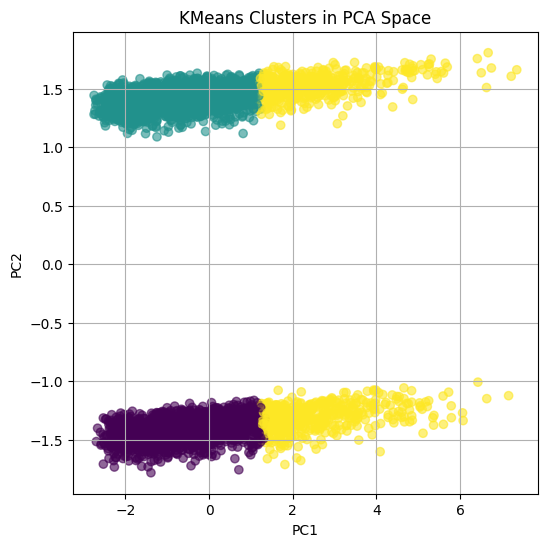

In [266]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters in PCA Space')
plt.grid(True)
plt.show()


In [ ]:
df_final['cluster'] = labels

In [274]:
df_final.select_dtypes(include=['number']).groupby('cluster').mean()

,age,income,complaint_count,avg_resolution_time,satisfaction_score,open_rate,click_rate,purchase_rate,unsubscribed,churn,ltv,log_income,tenure_days,ltv_log
cluster,,,,,,,,,,,,,,
0,46.096875,25274.190984,0.639062,2.480266,3.872411,0.233594,0.086109,0.045599,0.042708,0.092188,8563.748172,10.010934,916.568750,9.046904
1,46.764267,24531.243509,0.632000,2.489744,3.891115,0.229893,0.084448,0.044917,0.051733,0.100267,8569.414283,9.983296,908.189867,9.046550
2,45.007859,24599.941582,0.607073,2.450413,3.853841,0.514823,0.229460,0.131994,0.045187,0.100196,8559.903644,9.985980,902.140472,9.044945


In [ ]:
# Sort by importance and take top 15 features
top_features = feature_importance.sort_values(by='importance', ascending=False).head(15)

# Get their names as a list
top_feature_names = top_features['feature'].tolist()


print(top_feature_names)

['satisfaction_score', 'complaint_count', 'tenure_days', 'log_income', 'avg_resolution_time', 'income', 'open_rate', 'age', 'click_rate', 'purchase_rate', 'gender_Female', 'region_West', 'region_Central', 'gender_Male', 'region_East']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
from sklearn.model_selection import RandomizedSearchCV
search = RandomizedSearchCV()
search.fit(X_train, y_train)
print(search.best_params_)


TypeError: RandomizedSearchCV.__init__() missing 2 required positional arguments: 'estimator' and 'param_distributions'